# JP Morgan Quant V4 — Dual Attention Transformer

缺陷 1（Critical）：Cross-Stock Attention 是假的
你的 DualBlock 里，所谓的"cross-sectional"其实只是对 batch 内所有样本做了个 mean，然后用一个 gate 去调制。问题在于你的 DataLoader 是 shuffle=True 的——同一个 batch 里可能混合了不同日期、不同股票的样本，这个 batch mean 根本不代表"同一天的市场状态"。
MASTER 的做法是真正在同一时间步上把所有股票的 embedding 拼在一起做 multi-head attention arXiv，让模型学到"今天 NVDA 在涨，AMD 也在涨，这是板块联动"这样的信号。它同时建模了 momentary correlation（同一时刻的跨股票关系）和 cross-time correlation（不同时刻的跨股票关系） arXiv。
要实现真正的 cross-sectional attention，你的数据组织方式需要彻底改变——从"逐样本"变成"逐日期"，每个 batch 是同一天所有股票的数据。

缺陷 2（Critical）：数据规模严重不足
你有 ~60 只股票、9 年数据，大约 100K 样本。Quantformer 那篇论文收集了超过 4600 只股票、超过 500 万条滚动数据进行训练 arXiv。MASTER 使用的是 CSI300 和 CSI800，训练集跨度从 2008 年到 2020 年 AAAI。
你的模型有 ~800K 参数但只有 100K 样本，参数-样本比接近 1:100，对于金融这种低信噪比数据来说严重不足。一般经验是至少 1:1000。解决方案是扩大股票池到 S&P 500 全部成分股，或者大幅缩小模型。

缺陷 3（Critical）：没有 Validation Set，也没有 Rolling Window
你用的是一刀切的 70/30 split，没有 validation set。这意味着你无法做 early stopping，无法判断模型是欠拟合还是过拟合，也无法做超参数搜索。
MASTER 的标准做法是使用 Qlib 框架，训练集到 2020 Q1，验证集是 2020 Q2，测试集是 2020 Q3 到 2022 Q4 GitHub。更严格的做法是 rolling window——每隔一段时间用最近 N 年数据重新训练模型，模拟真实交易中的定期更新。
你的模型用 2016-2022 的数据训练，然后去预测 2023-2025——但市场结构在这三年里发生了巨大变化（利率环境、AI 热潮、地缘风险），一个 2022 年之前训练的模型很可能已经"过期"了。

缺陷 4（Moderate）：Loss Function 的排序信号太弱
你的 rank loss 是随机采样 pair 对比较，这种方式效率很低。最新研究在评估各种 ranking loss 对 Transformer 股票选择能力的影响 Springer，发现 listwise 方法（如 ListMLE、ListNet）比 pairwise 方法更有效，因为它直接优化整个排名序列，而不是一对一对比较。
另外，MASTER 使用 CSZcoreNorm 对标签做横截面标准化——按每天分组，用当天所有股票的 mean/std 归一化 target GitHub。这消除了不同市场状态下绝对收益率的差异，让模型专注学习"相对排名"。

缺陷 5（Moderate）：不具备市场状态适应能力
MASTER 的一个核心创新是利用市场指数信息来指导特征选择——在牛市和熊市中，有效的因子是不同的 arXiv。你的模型虽然输入了与 SP500 的相关性因子，但没有让市场状态动态影响模型内部的计算方式。
最近的研究也表明，在低信噪比环境下，对 attention 矩阵做动态稀疏化能带来 10-20% 的性能提升 arXiv，因为金融数据中大部分 attention 权重是噪声。

<img src="./update_img/JP_Morgen_V4_Update.png">

## 0. 依赖

In [1]:
!pip install yfinance -q

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
import os, pickle, copy
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. 下载数据（首次运行）

In [ ]:

# =====================================================================
# Cell 1 中替换 STOCK_UNIVERSE（~280 只股票）
# =====================================================================
# 按行业分组，方便后续做行业中性化

STOCK_UNIVERSE = {
    # ── Mega Cap Tech (15) ──
    'mega_tech': [
        'AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','AVGO',
        'ORCL','CRM','ADBE','AMD','INTC','CSCO','IBM',
    ],
    # ── Semiconductors (15) ──
    'semicon': [
        'QCOM','TXN','MU','AMAT','LRCX','KLAC','MRVL','ON',
        'ADI','SNPS','CDNS','NXPI','MCHP','SWKS','TER',
    ],
    # ── Cloud / SaaS / Cybersecurity (20) ──
    'cloud_saas': [
        'NOW','PANW','CRWD','NET','DDOG','ZS','SNOW','PLTR',
        'FTNT','ANET','INTU','WDAY','TEAM','HUBS','VEEV',
        'OKTA','MDB','BILL','ZI','ESTC',
    ],
    # ── Consumer Internet / Platforms (12) ──
    'consumer_internet': [
        'NFLX','PYPL','SQ','SHOP','UBER','ABNB','SNAP','PINS',
        'DASH','HOOD','APP','RBLX',
    ],
    # ── Energy — Oil & Gas (15) ──
    'energy_oil': [
        'XOM','CVX','COP','EOG','SLB','MPC','PSX','VLO',
        'OXY','DVN','HES','HAL','BKR','FANG','KMI',
    ],
    # ── Energy — Clean / Utilities (10) ──
    'energy_clean': [
        'FSLR','NEE','AES','CEG','VST','NRG','GEV',
        'ENPH','DUK','SO',
    ],
    # ── Financials — Banks & Asset Mgmt (20) ──
    'financials': [
        'JPM','GS','MS','BAC','WFC','C','SCHW','USB',
        'PNC','BK','COF','AXP','BLK','BX','KKR',
        'APO','ICE','CME','MCO','SPGI',
    ],
    # ── Insurance (6) ──
    'insurance': [
        'CB','PGR','TRV','AON','ALL','MET',
    ],
    # ── Healthcare — Pharma & Biotech (20) ──
    'pharma_biotech': [
        'LLY','JNJ','UNH','ABBV','MRK','PFE','AMGN','GILD',
        'BMY','REGN','VRTX','BIIB','MRNA','ILMN','SGEN',
        'ALNY','INCY','BGNE','EXAS','PCVX',
    ],
    # ── Healthcare — Devices & Services (12) ──
    'health_devices': [
        'ABT','TMO','ISRG','SYK','BSX','MDT','DHR','HCA',
        'EW','DXCM','PODD','HOLX',
    ],
    # ── Emerging Biotech / MedTech (10) ──
    'emerging_biotech': [
        'CRSP','NTLA','BEAM','EDIT','RARE','TWST',
        'RXRX','SDGR','TXG','NUVB',
    ],
    # ── Industrials / Aerospace (15) ──
    'industrials': [
        'CAT','GE','RTX','HON','BA','LMT','GD','NOC',
        'DE','ETN','PH','TT','LHX','TDG','HWM',
    ],
    # ── Consumer Staples (12) ──
    'consumer_staples': [
        'PG','KO','PEP','COST','WMT','MCD','SBUX','CL',
        'MDLZ','MNST','PM','MO',
    ],
    # ── Consumer Discretionary (12) ──
    'consumer_disc': [
        'HD','LOW','TJX','ROST','NKE','MAR','HLT','RCL',
        'GM','ORLY','BKNG','DIS',
    ],
    # ── Telecom / Media (6) ──
    'telecom': [
        'TMUS','VZ','T','CMCSA','WBD','CHTR',
    ],
    # ── REITs / Infrastructure (8) ──
    'reits': [
        'PLD','AMT','EQIX','DLR','SPG','WELL','CCI','PSA',
    ],
    # ── Materials / Mining (6) ──
    'materials': [
        'LIN','SHW','ECL','APD','NEM','FCX',
    ],
    # ── Transport / Logistics (6) ──
    'transport': [
        'UNP','CSX','NSC','FDX','UPS','WM',
    ],
    # ── Emerging AI / Robotics (8) ──
    'emerging_ai': [
        'PATH','AI','IONQ','SMCI','SOUN','BBAI','GFAI','AMBA',
    ],
}

In [ ]:
# 展平成列表
STOCK_UNIVERSE_FLAT = []
STOCK_SECTOR_MAP = {}  # ticker -> sector（后续行业中性化用）
for sector, tickers in STOCK_UNIVERSE.items():
    for t in tickers:
        if t not in STOCK_UNIVERSE_FLAT:
            STOCK_UNIVERSE_FLAT.append(t)
            STOCK_SECTOR_MAP[t] = sector

print(f"Stock universe: {len(STOCK_UNIVERSE_FLAT)} tickers across {len(STOCK_UNIVERSE)} sectors")
for sector, tickers in STOCK_UNIVERSE.items():
    print(f"  {sector:25s}: {len(tickers)} stocks")

In [ ]:
## 1. 下载数据（带日期范围校验）


MARKET_TICKERS = {'SPY':'SP500','QQQ':'Nasdaq100','XLE':'EnergySector','TLT':'Bond20Y','GLD':'Gold'}

# ========== 你只需要改这里 ==========
START_DATE = '2016-01-01'
END_DATE   = '2024-12-31'
# =====================================

SAVE_DIR = './v3_data'
META_FILE = os.path.join(SAVE_DIR, 'meta.json')  # 新增：记录数据的日期范围

import json

def save_meta(start, end, num_stocks):
    """保存数据的元信息（日期范围、股票数量）"""
    meta = {
        'start_date': start,
        'end_date': end,
        'num_stocks': num_stocks,
        'saved_at': pd.Timestamp.now().isoformat()
    }
    with open(META_FILE, 'w') as f:
        json.dump(meta, f, indent=2)

def check_date_range(start, end):
    """
    检查本地数据的日期范围是否覆盖请求的范围
    返回: (is_valid, reason)
    """
    if not os.path.exists(META_FILE):
        return False, '未找到 meta.json（旧版数据，无日期记录）'
    
    with open(META_FILE, 'r') as f:
        meta = json.load(f)
    
    saved_start = meta.get('start_date', '')
    saved_end   = meta.get('end_date', '')
    
    # 检查: 本地数据的起始日期 <= 请求的起始日期
    #       本地数据的结束日期 >= 请求的结束日期
    if saved_start > start:
        return False, f'本地数据起始 {saved_start} 晚于请求的 {start}'
    if saved_end < end:
        return False, f'本地数据结束 {saved_end} 早于请求的 {end}'
    
    print(f'✅ 日期校验通过: 本地 [{saved_start} ~ {saved_end}] 覆盖请求 [{start} ~ {end}]')
    return True, 'OK'

def download_all(start=START_DATE, end=END_DATE):
    print(f'下载股票数据 [{start} ~ {end}]...')
    raw = {}
    failed = []
    for t in STOCK_UNIVERSE_FLAT:
        try:
            df = yf.download(t, start=start, end=end, progress=False)
            if len(df) > 200:
                raw[t] = df
                print(f'  ✓ {t}: {len(df)}')
            else:
                failed.append(t)
        except:
            failed.append(t)

    if failed:
        print(f'\n  ✗ Failed ({len(failed)}): {failed}')

    print(f'\n下载市场基准...')
    mkt = {}
    for t, name in MARKET_TICKERS.items():
        try:
            df = yf.download(t, start=start, end=end, progress=False)
            if len(df) > 200:
                mkt[name] = df['Close'].values.flatten()
                mkt[f'{name}_idx'] = df.index
                print(f'  ✓ {name}')
        except: print(f'  ✗ {name}')

    print(f'\n获取基本面...')
    fund = {}
    for t in raw.keys():
        try:
            info = yf.Ticker(t).info
            fund[t] = {
                'pe': info.get('trailingPE', np.nan),
                'pb': info.get('priceToBook', np.nan),
                'market_cap': info.get('marketCap', np.nan),
                'dividend_yield': info.get('dividendYield', 0) or 0,
                'roe': info.get('returnOnEquity', np.nan),
            }
        except:
            fund[t] = {}

    print(f'\n✅ Downloaded {len(raw)} stocks')
    return raw, mkt, fund

def save_data(raw, mkt, fund, start=START_DATE, end=END_DATE):
    os.makedirs(SAVE_DIR, exist_ok=True)
    for t, df in raw.items():
        df_save = df.copy()
        df_save.columns = [str(c).split(',')[0].strip().strip("('\"") for c in df_save.columns]
        df_save.to_csv(os.path.join(SAVE_DIR, f'{t}.csv'))
    with open(os.path.join(SAVE_DIR, 'market.pkl'), 'wb') as f:
        pickle.dump(mkt, f)
    with open(os.path.join(SAVE_DIR, 'fund.pkl'), 'wb') as f:
        pickle.dump(fund, f)
    
    # 新增：保存元信息
    save_meta(start, end, len(raw))
    print(f'✅ 保存到 {SAVE_DIR}/ ({len(raw)} stocks, {start} ~ {end})')

def load_data():
    raw = {}
    for fname in os.listdir(SAVE_DIR):
        if fname.endswith('.csv'):
            t = fname.replace('.csv', '')
            raw[t] = pd.read_csv(os.path.join(SAVE_DIR, fname), index_col=0, parse_dates=True)
    with open(os.path.join(SAVE_DIR, 'market.pkl'), 'rb') as f:
        mkt = pickle.load(f)
    with open(os.path.join(SAVE_DIR, 'fund.pkl'), 'rb') as f:
        fund = pickle.load(f)
    print(f'✅ 从 {SAVE_DIR}/ 加载 ({len(raw)} stocks)')
    return raw, mkt, fund

# ========== 主逻辑：校验 → 加载 or 重新下载 ==========

data_valid = False

if os.path.exists(os.path.join(SAVE_DIR, 'market.pkl')):
    data_valid, reason = check_date_range(START_DATE, END_DATE)
    if not data_valid:
        print(f'⚠️  日期不匹配: {reason}')
        print(f'   正在重新下载 [{START_DATE} ~ {END_DATE}]...\n')

if data_valid:
    raw_data, market_data, fundamentals = load_data()
else:
    raw_data, market_data, fundamentals = download_all(START_DATE, END_DATE)
    save_data(raw_data, market_data, fundamentals, START_DATE, END_DATE)

✅ 日期校验通过: 本地 [2016-01-01 ~ 2025-12-31] 覆盖请求 [2016-01-01 ~ 2024-12-31]
✅ 从 ./v3_data/ 加载 (63 stocks)


## 2. V3 因子工程（~30 factors）

In [4]:
def compute_v3_factors(df, market_data, fund_data=None):
    f = pd.DataFrame(index=df.index)
    c = pd.Series(df['Close'].values.flatten(), index=df.index)
    v = pd.Series(df['Volume'].values.flatten(), index=df.index)
    h = pd.Series(df['High'].values.flatten(), index=df.index)
    l = pd.Series(df['Low'].values.flatten(), index=df.index)
    o = pd.Series(df['Open'].values.flatten(), index=df.index)
    dr = c.pct_change()

    for n in [5,10,20,60]: f[f'ret_{n}d'] = c.pct_change(n)
    f['mom_accel'] = f['ret_5d'] - f['ret_5d'].shift(5)

    f['vol_20d'] = dr.rolling(20).std()
    f['vol_ratio'] = dr.rolling(5).std() / dr.rolling(20).std()
    f['vol_accel'] = f['vol_20d'].pct_change(5)
    f['intraday_vol'] = ((h - l) / c).rolling(20).mean()
    f['vol_spread'] = f['intraday_vol'] - f['vol_20d']

    f['vol_ma_ratio'] = v / v.rolling(20).mean()
    f['volume_trend'] = v.rolling(5).mean() / v.rolling(20).mean() - 1
    obv = (dr.apply(np.sign) * v).rolling(20).sum()
    f['obv_norm'] = obv / v.rolling(20).sum()
    vwap = (c * v).rolling(20).sum() / v.rolling(20).sum()
    f['vwap_dev'] = c / vwap - 1

    f['bb_pos'] = (c - c.rolling(20).mean()) / (c.rolling(20).std() * 2)
    f['ma_cross_s'] = c.rolling(5).mean() / c.rolling(20).mean() - 1
    f['ma_cross_l'] = c.rolling(20).mean() / c.rolling(60).mean() - 1

    delta = c.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss_v = (-delta.where(delta < 0, 0)).rolling(14).mean()
    f['rsi'] = (100 - 100 / (1 + gain / loss_v.replace(0, np.nan))) / 100 - 0.5

    rmin, rmax = c.rolling(60).min(), c.rolling(60).max()
    f['price_pos'] = ((c - rmin) / (rmax - rmin).replace(0, np.nan)) - 0.5
    f['price_range'] = (h - l) / c

    for name in ['SP500','Nasdaq100','EnergySector']:
        if name in market_data:
            ref = pd.Series(market_data[name], index=market_data[f'{name}_idx'])
            ref_a = ref.reindex(df.index, method='ffill')
            f[f'rel_{name}'] = c.pct_change(20) - ref_a.pct_change(20)
            f[f'corr_{name}'] = dr.rolling(60).corr(ref_a.pct_change())

    f['ret_252d'] = c.pct_change(252)
    f['ma200_dev'] = c / c.rolling(200).mean() - 1
    f['sharpe_20d'] = f['ret_20d'] / f['vol_20d'].replace(0, np.nan)
    f['gap'] = (o / c.shift(1) - 1).rolling(5).mean()

    if fund_data:
        for k in ['pe','pb','market_cap','dividend_yield','roe']:
            val = fund_data.get(k, np.nan)
            f[f'f_{k}'] = val if (not np.isnan(val) if isinstance(val, float) else True) else 0.0

    return f.dropna()

sample = compute_v3_factors(raw_data[list(raw_data.keys())[0]], market_data, fundamentals.get(list(raw_data.keys())[0], {}))
print(f'因子数: {sample.shape[1]}')
print(list(sample.columns))

因子数: 35
['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'mom_accel', 'vol_20d', 'vol_ratio', 'vol_accel', 'intraday_vol', 'vol_spread', 'vol_ma_ratio', 'volume_trend', 'obv_norm', 'vwap_dev', 'bb_pos', 'ma_cross_s', 'ma_cross_l', 'rsi', 'price_pos', 'price_range', 'rel_SP500', 'corr_SP500', 'rel_Nasdaq100', 'corr_Nasdaq100', 'rel_EnergySector', 'corr_EnergySector', 'ret_252d', 'ma200_dev', 'sharpe_20d', 'gap', 'f_pe', 'f_pb', 'f_market_cap', 'f_dividend_yield', 'f_roe']


## 3. 数据集（滚动标准化 + 日期对齐）

## update 1: tranfer to rolling window

<img src="./update_img/JP_Morgen_V4_rolling_window.png">

In [5]:
# =====================================================================
# Cell 3 替换：加入日期诊断 + 自动剔除短数据股票
# =====================================================================

LOOKBACK = 20
SCALER_WINDOW = 120

def prepare_full_dataset(raw_data, market_data, fundamentals,
                         lookback=20, scaler_window=120,
                         min_history_years=5):
    """
    修复版：
    1. 先诊断每只股票的因子数据起始日期
    2. 自动剔除历史太短的股票（< min_history_years）
    3. 再取交集
    """
    all_stock = {}
    stock_date_ranges = {}

    for t, df in raw_data.items():
        fac = compute_v3_factors(df, market_data, fundamentals.get(t, {}))
        cs = pd.Series(df['Close'].values.flatten(), index=df.index)
        fut = cs.pct_change(5).shift(-5)
        idx = fac.index.intersection(fut.dropna().index)
        if len(idx) == 0:
            continue
        all_stock[t] = {'factors': fac.loc[idx], 'target': fut.loc[idx]}
        stock_date_ranges[t] = (idx.min(), idx.max())

    # ---- 诊断：打印每只股票的数据范围 ----
    print("=" * 60)
    print("Stock date ranges (after factor computation):")
    print("=" * 60)
    ranges_df = pd.DataFrame([
        {'ticker': t, 'start': r[0].strftime('%Y-%m-%d'), 'end': r[1].strftime('%Y-%m-%d'),
         'days': len(all_stock[t]['factors'])}
        for t, r in stock_date_ranges.items()
    ]).sort_values('start')
    print(ranges_df.to_string(index=False))

    # ---- 剔除历史太短的股票 ----
    cutoff = pd.Timestamp.now() - pd.DateOffset(years=min_history_years)
    short_stocks = [t for t, r in stock_date_ranges.items() if r[0] > cutoff]

    if short_stocks:
        print(f"\n⚠️  Removing {len(short_stocks)} stocks with < {min_history_years} years of data:")
        for t in short_stocks:
            r = stock_date_ranges[t]
            print(f"    {t}: starts {r[0].strftime('%Y-%m-%d')} (too late)")
            del all_stock[t]
    
    if len(all_stock) == 0:
        raise ValueError("No stocks left after filtering! Lower min_history_years.")

    print(f"\n✅ Keeping {len(all_stock)} stocks")

    nf = list(all_stock.values())[0]['factors'].shape[1]

    # ---- 取交集 ----
    all_dates = None
    for d in all_stock.values():
        s = set(d['factors'].index)
        all_dates = s if all_dates is None else all_dates.intersection(s)
    all_dates = sorted(list(all_dates))
    print(f"Common trading days: {len(all_dates)}")
    print(f"Date range: {all_dates[0].strftime('%Y-%m-%d')} ~ {all_dates[-1].strftime('%Y-%m-%d')}")

    # ---- CSZscoreNorm: 横截面标准化 target ----
    # 每天按所有股票的 mean/std 归一化，消除市场整体涨跌的影响
    # 归一化后 target 表示"这只股票相对当天所有股票的表现"
    print("\nApplying CSZscoreNorm to targets...")

    # 1) 收集每天每只股票的 raw target
    daily_targets = {}  # {date: {ticker: raw_target}}
    for t, d in all_stock.items():
        tgt = d['target'].loc[d['target'].index.isin(all_dates)]
        for dt, val in tgt.items():
            if dt not in daily_targets:
                daily_targets[dt] = {}
            daily_targets[dt][t] = val

    # 2) 按天计算 mean/std，归一化
    cs_targets = {}  # {(ticker, date): normalized_target}
    n_clipped = 0
    for dt, ticker_vals in daily_targets.items():
        vals = np.array(list(ticker_vals.values()))
        vals_clean = vals[~np.isnan(vals)]
        if len(vals_clean) < 3:
            continue
        mu = np.mean(vals_clean)
        sd = np.std(vals_clean)
        if sd < 1e-8:
            sd = 1.0
        for t, v in ticker_vals.items():
            z = (v - mu) / sd
            # 裁剪极端值（MASTER 论文 DropExtremeLabel 的简化版）
            if abs(z) > 3.0:
                z = np.clip(z, -3.0, 3.0)
                n_clipped += 1
            cs_targets[(t, dt)] = z

    print(f"  CS-normalized {len(cs_targets):,} targets | Clipped {n_clipped} extreme values (|z|>3)")

    # ---- 构建样本 ----
    X, y, tks, dts = [], [], [], []
    for t, d in all_stock.items():
        fdf = d['factors'].loc[d['factors'].index.isin(all_dates)]
        tgt = d['target'].loc[d['target'].index.isin(all_dates)]
        fn, tn_raw, dl = fdf.values, tgt.values, fdf.index.tolist()
        for i in range(max(scaler_window, lookback), len(fn)):
            w = fn[max(0, i - scaler_window):i]
            mu, sd = np.nanmean(w, axis=0), np.nanstd(w, axis=0)
            sd[sd < 1e-8] = 1.0
            s = (fn[i - lookback:i] - mu) / sd
            if np.any(np.isnan(s)):
                continue
            # 用 CS-normalized target 代替 raw target
            cs_key = (t, dl[i])
            if cs_key not in cs_targets:
                continue
            X.append(s.astype(np.float32))
            y.append(cs_targets[cs_key])        # CS-normalized (训练用)
            tks.append(t)
            dts.append(dl[i])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    # 构建 raw target 查找表（回测用）
    raw_targets = {}
    for t, d in all_stock.items():
        tgt = d['target'].loc[d['target'].index.isin(all_dates)]
        for dt, val in tgt.items():
            raw_targets[(t, dt)] = val

    # 为每个样本取对应的 raw return
    y_raw = np.array([raw_targets.get((t, d), np.nan)
                      for t, d in zip(tks, dts)], dtype=np.float32)

    print(f"\nTotal samples: {len(X):,} | Factors: {nf}")
    print(f"Sample date range: {min(dts).strftime('%Y-%m-%d')} ~ {max(dts).strftime('%Y-%m-%d')}")
    print(f"Target stats — CS-norm: mean={y.mean():.4f}, std={y.std():.4f}")
    print(f"Target stats — Raw:     mean={y_raw.mean():.4f}, std={y_raw.std():.4f}")

    return {
        'X': X, 'y': y,            # y = CS-normalized (训练用)
        'y_raw': y_raw,             # y_raw = 真实收益率 (回测用)
        'tickers': tks, 'dates': dts,
        'num_factors': nf
    }


full_data = prepare_full_dataset(raw_data, market_data, fundamentals, min_history_years=5)
NUM_FACTORS = full_data['num_factors']

Stock date ranges (after factor computation):
ticker      start        end  days
  AAPL 2017-01-03 2025-12-22  2256
  META 2017-01-03 2025-12-22  2249
   XOM 2017-01-03 2025-12-22  2256
  MRVL 2017-01-03 2025-12-22  2256
  MSFT 2017-01-03 2025-12-22  2256
    MU 2017-01-03 2025-12-22  2256
   NEE 2017-01-03 2025-12-22  2256
  NFLX 2017-01-03 2025-12-22  2256
   NOW 2017-01-03 2025-12-22  2251
  NVDA 2017-01-03 2025-12-22  2256
    ON 2017-01-03 2025-12-22  2254
  ORCL 2017-01-03 2025-12-22  2256
  LRCX 2017-01-03 2025-12-22  2255
   OXY 2017-01-03 2025-12-22  2253
    PG 2017-01-03 2025-12-22  2256
   PSX 2017-01-03 2025-12-22  2256
  PYPL 2017-01-03 2025-12-22  2256
  QCOM 2017-01-03 2025-12-22  2256
  SEDG 2017-01-03 2025-12-22  2256
  SHOP 2017-01-03 2025-12-22  2256
   SLB 2017-01-03 2025-12-22  2256
  TSLA 2017-01-03 2025-12-22  2256
   TXN 2017-01-03 2025-12-22  2256
   UNH 2017-01-03 2025-12-22  2256
   VLO 2017-01-03 2025-12-22  2256
  PANW 2017-01-03 2025-12-22  2256
  KLAC 20

In [6]:
class SDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

## 4. V3 Model

In [7]:
class Time2Vec(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.lin = nn.Linear(1, 1)
        self.per = nn.Linear(1, d - 1)
    def forward(self, T, dev):
        t = (torch.arange(T, dtype=torch.float32, device=dev) / T).unsqueeze(-1)
        return torch.cat([self.lin(t), torch.sin(self.per(t))], dim=-1)

class DualBlock(nn.Module):
    def __init__(self, d, nh, ff, drop):
        super().__init__()
        self.temp = nn.TransformerEncoderLayer(d_model=d, nhead=nh, dim_feedforward=ff, dropout=drop, batch_first=True, norm_first=True)
        self.gate = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        x = self.temp(x)
        g = self.gate(x.mean(dim=0, keepdim=True))
        return self.norm(x * g + x)

class QuantV3(nn.Module):
    def __init__(self, nf, d=192, nh=6, nl=4, ff=384, drop=0.15):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(nf, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop))
        self.t2v = Time2Vec(d)
        self.blocks = nn.ModuleList([DualBlock(d, nh, ff, drop) for _ in range(nl)])
        self.pool = nn.Sequential(nn.Linear(d, d//4), nn.Tanh(), nn.Linear(d//4, 1))
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d//2), nn.GELU(), nn.Dropout(drop), nn.Linear(d//2, d//4), nn.GELU(), nn.Dropout(drop*0.5), nn.Linear(d//4, 1))
        self.apply(self._iw)
    def _iw(self, m):
        if isinstance(m, nn.Linear): nn.init.xavier_normal_(m.weight); (m.bias is not None) and nn.init.zeros_(m.bias)
    def forward(self, x):
        B, T, _ = x.shape
        x = self.proj(x) + self.t2v(T, x.device).unsqueeze(0)
        for b in self.blocks: x = b(x)
        w = torch.softmax(self.pool(x), dim=1)
        return self.head((x * w).sum(dim=1))

model = QuantV3(nf=NUM_FACTORS, d=192, nh=6, nl=4, ff=384, drop=0.15).to(device)
print(f'V3 params: {sum(p.numel() for p in model.parameters()):,}')

V3 params: 1,526,690


## 5. Combined Loss (Rank + MSE + IC)

In [8]:
class CombinedLoss(nn.Module):
    def __init__(self, rw=0.5, mw=0.2, iw=0.3, margin=0.001):
        super().__init__()
        self.rw, self.mw, self.iw, self.margin = rw, mw, iw, margin
        self.mse = nn.MSELoss()
    def forward(self, pred, target):
        p, t = pred.squeeze(), target.squeeze()
        n = len(p)
        if n < 4: return self.mse(p, t), 0., self.mse(p,t).item(), 0.
        np_ = min(n*4, 512)
        ii, jj = torch.randint(0,n,(np_,),device=p.device), torch.randint(0,n,(np_,),device=p.device)
        rl = torch.clamp(self.margin - torch.sign(t[ii]-t[jj]) * (p[ii]-p[jj]), min=0).mean()
        ml = self.mse(p, t)
        pm, tm = p - p.mean(), t - t.mean()
        ic = (pm * tm).mean() / ((pm.std()+1e-8) * (tm.std()+1e-8))
        total = self.rw * rl + self.mw * ml + self.iw * (1 - ic)
        return total, rl.item(), ml.item(), ic.item()

criterion = CombinedLoss()
print('Loss: 50% Rank + 20% MSE + 30% IC')

Loss: 50% Rank + 20% MSE + 30% IC


## 6. 训练（CosineAnnealingLR T_max=40, 80 epochs）

In [9]:
# =====================================================================
# Cell 6：Rolling Window 训练（修复日期类型问题）
# =====================================================================

from dateutil.relativedelta import relativedelta

def generate_folds(dates, val_months=6, test_months=6, min_train_years=3):
    # 统一转成 Python datetime（消除 Timestamp vs datetime 不兼容）
    unique_dates = sorted(set([pd.Timestamp(d).to_pydatetime() for d in dates]))
    first_date = unique_dates[0]
    last_date = unique_dates[-1]

    print(f"  [debug] Date range: {first_date.strftime('%Y-%m-%d')} ~ {last_date.strftime('%Y-%m-%d')}")
    print(f"  [debug] Date type: {type(first_date)}")
    print(f"  [debug] Total unique dates: {len(unique_dates)}")

    folds = []
    test_start = first_date + relativedelta(years=min_train_years, months=val_months)
    print(f"  [debug] First test_start: {test_start.strftime('%Y-%m-%d')}")

    while True:
        test_end = test_start + relativedelta(months=test_months)
        if test_end > last_date:
            # 如果 test_end 超出但 test_start 还在范围内，用 last_date 作为结尾
            if test_start < last_date:
                test_end = last_date
            else:
                break

        val_start = test_start - relativedelta(months=val_months)
        train_end = val_start

        train_dates = [d for d in unique_dates if first_date <= d < train_end]
        val_dates = [d for d in unique_dates if val_start <= d < test_start]
        test_dates = [d for d in unique_dates if test_start <= d < test_end]

        if len(train_dates) > 100 and len(val_dates) > 20 and len(test_dates) > 20:
            folds.append({
                'train_start': first_date,
                'train_end': train_end,
                'val_start': val_start,
                'val_end': test_start,
                'test_start': test_start,
                'test_end': test_end,
                'n_train_days': len(train_dates),
                'n_val_days': len(val_dates),
                'n_test_days': len(test_dates),
            })

        test_start = test_end
        # 安全退出：如果 test_end 已经是 last_date 了，不再继续
        if test_end >= last_date:
            break

    return folds


def get_mask(dates, start, end):
    """返回 boolean mask，统一转 datetime 再比较"""
    start_dt = pd.Timestamp(start).to_pydatetime()
    end_dt = pd.Timestamp(end).to_pydatetime()
    return np.array([
        (start_dt <= pd.Timestamp(d).to_pydatetime() < end_dt) for d in dates
    ])


def train_one_fold(fold_info, full_data, model_class, model_kwargs,
                   num_epochs=80, patience=10, batch_size=256, lr=3e-4):
    dates = full_data['dates']
    X, y = full_data['X'], full_data['y']

    tr_mask = get_mask(dates, fold_info['train_start'], fold_info['train_end'])
    va_mask = get_mask(dates, fold_info['val_start'], fold_info['val_end'])
    te_mask = get_mask(dates, fold_info['test_start'], fold_info['test_end'])

    X_tr, y_tr = X[tr_mask], y[tr_mask]
    X_va, y_va = X[va_mask], y[va_mask]
    X_te, y_te = X[te_mask], y[te_mask]
    tickers_te = [t for t, m in zip(full_data['tickers'], te_mask) if m]
    dates_te = [d for d, m in zip(dates, te_mask) if m]
    y_raw_te = full_data['y_raw'][te_mask]  # 真实收益率用于回测

    print(f"  Train: {tr_mask.sum():,} | Val: {va_mask.sum():,} | Test: {te_mask.sum():,}")

    if tr_mask.sum() == 0 or va_mask.sum() == 0 or te_mask.sum() == 0:
        print("  ⚠️  Empty split detected, skipping this fold")
        return pd.DataFrame(), 0.0, 0.0

    train_ds = SDS(X_tr, y_tr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = model_class(**model_kwargs).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs // 2)
    criterion = CombinedLoss()

    best_val_ic = -np.inf
    best_state = None
    no_improve = 0

    for ep in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss, _, _, _ = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            va_tensor = torch.FloatTensor(X_va).to(device)
            va_preds = []
            for i in range(0, len(va_tensor), 512):
                p = model(va_tensor[i:i+512]).squeeze().cpu().numpy()
                if p.ndim == 0: p = np.array([p])
                va_preds.extend(p.tolist())
            va_preds = np.array(va_preds)

        val_ic, _ = stats.spearmanr(va_preds, y_va)
        if np.isnan(val_ic):
            val_ic = 0.0

        if val_ic > best_val_ic:
            best_val_ic = val_ic
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if (ep + 1) % 20 == 0:
            print(f"    Epoch {ep+1:3d} | Val IC: {val_ic:.4f} | Best: {best_val_ic:.4f} | Patience: {no_improve}/{patience}")

        if no_improve >= patience:
            print(f"    Early stop at epoch {ep+1} (best Val IC: {best_val_ic:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        te_tensor = torch.FloatTensor(X_te).to(device)
        te_preds = []
        for i in range(0, len(te_tensor), 512):
            p = model(te_tensor[i:i+512]).squeeze().cpu().numpy()
            if p.ndim == 0: p = np.array([p])
            te_preds.extend(p.tolist())

    result = pd.DataFrame({
        'ticker': tickers_te,
        'date': dates_te,
        'predicted': te_preds,
        'actual': y_raw_te[:len(te_preds)]  # 回测用真实收益率
    })

    test_ic, _ = stats.spearmanr(result['predicted'], result['actual'])
    print(f"  ✅ Fold done | Test IC: {test_ic:.4f} | Best Val IC: {best_val_ic:.4f}\n")
    return result, best_val_ic, test_ic



In [11]:
# =====================================================================
# 主训练流程
# =====================================================================

# 根据实际数据范围自动计算合理的参数
date_range_years = (max(full_data['dates']) - min(full_data['dates'])).days / 365.25
print(f"Data spans {date_range_years:.1f} years")

if date_range_years >= 7:
    mt, vm, tm = 3, 6, 6      # 充足数据：3年训练 + 6月验证 + 6月测试
elif date_range_years >= 4:
    mt, vm, tm = 2, 4, 4      # 中等数据：2年训练 + 4月验证 + 4月测试
else:
    mt, vm, tm = 1, 3, 3      # 少量数据：1年训练 + 3月验证 + 3月测试

print(f"Auto config: min_train={mt}yr, val={vm}mo, test={tm}mo")

folds = generate_folds(
    full_data['dates'],
    val_months=vm,
    test_months=tm,
    min_train_years=mt
)

print(f"\n共 {len(folds)} 个 fold:\n")
for i, f in enumerate(folds):
    print(f"  Fold {i+1}: Train [{f['train_start'].strftime('%Y-%m')} ~ {f['train_end'].strftime('%Y-%m')}] "
          f"| Val [{f['val_start'].strftime('%Y-%m')} ~ {f['val_end'].strftime('%Y-%m')}] "
          f"| Test [{f['test_start'].strftime('%Y-%m')} ~ {f['test_end'].strftime('%Y-%m')}] "
          f"({f['n_train_days']}/{f['n_val_days']}/{f['n_test_days']} days)")

if len(folds) == 0:
    print("\n❌ 没有生成任何 fold！请检查:")
    print(f"   数据日期范围: {min(full_data['dates'])} ~ {max(full_data['dates'])}")
    print(f"   min_train_years=3 + val_months=6 需要至少 3.5 年数据")
    print("   尝试减小 min_train_years=2 或 val_months=3")
else:
    model_kwargs = dict(nf=NUM_FACTORS, d=192, nh=8, nl=4, ff=384, drop=0.15)

    all_results = []
    fold_metrics = []

    for i, fold in enumerate(folds):
        print(f"{'='*60}")
        print(f"Fold {i+1}/{len(folds)}: test [{fold['test_start'].strftime('%Y-%m-%d')} ~ {fold['test_end'].strftime('%Y-%m-%d')}]")
        print(f"{'='*60}")

        result, val_ic, test_ic = train_one_fold(
            fold_info=fold,
            full_data=full_data,
            model_class=QuantV3,
            model_kwargs=model_kwargs,
            num_epochs=80,
            patience=10,
            batch_size=256,
            lr=3e-4
        )

        # 只保留非空结果
        if len(result) > 0:
            all_results.append(result)
            fold_metrics.append({
                'fold': i + 1,
                'test_start': fold['test_start'],
                'test_end': fold['test_end'],
                'val_ic': val_ic,
                'test_ic': test_ic,
                'n_samples': len(result)
            })

    if len(all_results) == 0:
        print("\n❌ 所有 fold 都为空，请检查 get_mask 的日期匹配")
    else:
        res_final = pd.concat(all_results, ignore_index=True).sort_values('date').reset_index(drop=True)

        print(f"\n{'='*60}")
        print("Rolling Window Summary")
        print(f"{'='*60}")
        metrics_df = pd.DataFrame(fold_metrics)
        for _, row in metrics_df.iterrows():
            print(f"  Fold {row['fold']}: Val IC={row['val_ic']:.4f} | Test IC={row['test_ic']:.4f} | "
                  f"[{row['test_start'].strftime('%Y-%m')} ~ {row['test_end'].strftime('%Y-%m')}]")

        mean_val_ic = metrics_df['val_ic'].mean()
        mean_test_ic = metrics_df['test_ic'].mean()
        print(f"\n  Avg Val IC:  {mean_val_ic:.4f}")
        print(f"  Avg Test IC: {mean_test_ic:.4f}")
        print(f"  IC gap (val-test): {mean_val_ic - mean_test_ic:.4f}")

        if abs(mean_val_ic - mean_test_ic) > 0.03:
            print("  ⚠️  Val/Test IC 差距较大，可能存在过拟合")
        else:
            print("  ✅ Val/Test IC 差距合理")

        print(f"\n总预测样本: {len(res_final):,}")
        print(f"日期覆盖: {res_final['date'].min().strftime('%Y-%m-%d')} ~ {res_final['date'].max().strftime('%Y-%m-%d')}")

Data spans 4.8 years
Auto config: min_train=2yr, val=4mo, test=4mo
  [debug] Date range: 2021-03-12 ~ 2025-12-22
  [debug] Date type: <class 'datetime.datetime'>
  [debug] Total unique dates: 1192
  [debug] First test_start: 2023-07-12

共 8 个 fold:

  Fold 1: Train [2021-03 ~ 2023-03] | Val [2023-03 ~ 2023-07] | Test [2023-07 ~ 2023-11] (503/83/87 days)
  Fold 2: Train [2021-03 ~ 2023-07] | Val [2023-07 ~ 2023-11] | Test [2023-11 ~ 2024-03] (586/87/81 days)
  Fold 3: Train [2021-03 ~ 2023-11] | Val [2023-11 ~ 2024-03] | Test [2024-03 ~ 2024-07] (673/81/82 days)
  Fold 4: Train [2021-03 ~ 2024-03] | Val [2024-03 ~ 2024-07] | Test [2024-07 ~ 2024-11] (754/82/86 days)
  Fold 5: Train [2021-03 ~ 2024-07] | Val [2024-07 ~ 2024-11] | Test [2024-11 ~ 2025-03] (836/86/73 days)
  Fold 6: Train [2021-03 ~ 2024-11] | Val [2024-11 ~ 2025-03] | Test [2025-03 ~ 2025-07] (922/73/84 days)
  Fold 7: Train [2021-03 ~ 2025-03] | Val [2025-03 ~ 2025-07] | Test [2025-07 ~ 2025-11] (995/84/85 days)
  Fold 8

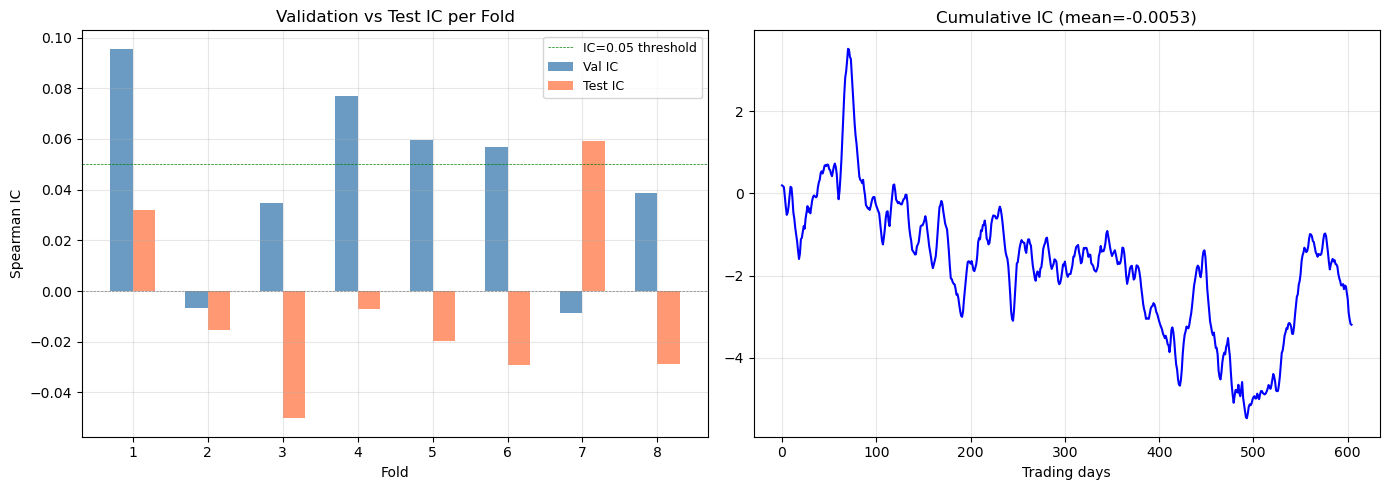

In [12]:
# =====================================================================
# Cell 6.5（新增）: Fold IC 可视化
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 每个 fold 的 val IC vs test IC
ax = axes[0]
x = range(1, len(fold_metrics) + 1)
ax.bar([i - 0.15 for i in x], metrics_df['val_ic'], width=0.3, color='steelblue', label='Val IC', alpha=0.8)
ax.bar([i + 0.15 for i in x], metrics_df['test_ic'], width=0.3, color='coral', label='Test IC', alpha=0.8)
ax.axhline(y=0, color='gray', ls='--', lw=0.5)
ax.axhline(y=0.05, color='green', ls='--', lw=0.5, label='IC=0.05 threshold')
ax.set_xlabel('Fold')
ax.set_ylabel('Spearman IC')
ax.set_title('Validation vs Test IC per Fold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 右图: 累计 IC 曲线（用合并后的 res_final）
ax = axes[1]
daily_ic = []
for dt, g in res_final.groupby('date'):
    if len(g) < 5:
        continue
    ic, _ = stats.spearmanr(g['predicted'], g['actual'])
    if not np.isnan(ic):
        daily_ic.append(ic)
ax.plot(np.cumsum(daily_ic), 'b-', lw=1.5)
ax.set_title(f'Cumulative IC (mean={np.mean(daily_ic):.4f})')
ax.set_xlabel('Trading days')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 回测（含交易成本 + 信号方向检测）

加入空仓判断，是否面对极度市场波动情况

In [13]:
# =====================================================================
# Cell 7 替换：回测（直接用 res_final，不再需要 model 推理）
# =====================================================================

TX_COST = 0.001
REBAL_FREQ = 5
TOP_N = 3

def backtest_from_predictions(res, top_n=TOP_N, tx=TX_COST, rf=REBAL_FREQ, rev=False):
    """
    与原版的区别：
    - 输入是已有的预测 DataFrame（res_final），不再调用 model
    - 其余逻辑完全相同
    """
    res = res.copy()
    if rev:
        res['predicted'] = -res['predicted']

    dg = res.groupby('date')
    rd = sorted(res['date'].unique())[::rf]
    rows, pl, ps = [], set(), set()

    for dt in rd:
        if dt not in dg.groups:
            continue
        g = dg.get_group(dt)
        if len(g) < 2 * top_n:
            continue
        g = g.sort_values('predicted', ascending=False)
        lt = set(g.head(top_n)['ticker'])
        st = set(g.tail(top_n)['ticker'])
        lr = g.head(top_n)['actual'].mean()
        sr = -g.tail(top_n)['actual'].mean()
        to = (len(lt - pl) + len(st - ps)) / (2 * top_n)
        cost = to * tx * 2
        gross = (lr + sr) / 2
        rows.append({
            'date': dt,
            'long_return': lr,
            'short_return': sr,
            'gross_return': gross,
            'net_return': gross - cost,
            'turnover': to,
            'cost': cost
        })
        pl, ps = lt, st

    return pd.DataFrame(rows).sort_values('date').reset_index(drop=True)


# --- 检测信号方向 ---
print('Testing signal direction...')
for rev, lab in [(False, '原始'), (True, '反转')]:
    bt = backtest_from_predictions(res_final, rev=rev)
    r = bt['net_return']
    cum = (1 + r).cumprod()
    tot = cum.iloc[-1] - 1
    ppy = 252 / REBAL_FREQ
    ar = (1 + tot) ** (ppy / len(r)) - 1
    av = r.std() * np.sqrt(ppy)
    sh = (ar - 0.04) / av if av > 0 else 0
    print(f'  [{lab}] Net:{tot:.2%} | Ann:{ar:.2%} | Sharpe:{sh:.2f} | TO:{bt["turnover"].mean():.0%}')

bt_o = backtest_from_predictions(res_final, rev=False)
bt_r = backtest_from_predictions(res_final, rev=True)
use_rev = (1 + bt_r['net_return']).cumprod().iloc[-1] > (1 + bt_o['net_return']).cumprod().iloc[-1]
bt_final = bt_r if use_rev else bt_o
# 保留对应方向的 res_final 用于后续分析
res_plot = res_final.copy()
if use_rev:
    res_plot['predicted'] = -res_plot['predicted']
print(f'\n✅ Using {"reversed" if use_rev else "original"} signal | Trades: {len(bt_final)}')



Testing signal direction...
  [原始] Net:-36.73% | Ann:-17.36% | Sharpe:-1.43 | TO:65%
  [反转] Net:9.42% | Ann:3.82% | Sharpe:-0.01 | TO:65%

✅ Using reversed signal | Trades: 121


## 8. 评估

In [14]:
# =====================================================================
# Cell 8 替换：评估（不变，但加上 rolling window 的额外指标）
# =====================================================================

def evaluate(bt, rf=REBAL_FREQ):
    ppy = 252 / rf
    for lab, col in [('Gross (no cost)', 'gross_return'), ('Net (with cost)', 'net_return')]:
        r = bt[col]
        cum = (1 + r).cumprod()
        tot = cum.iloc[-1] - 1
        n = len(r)
        ar = (1 + tot) ** (ppy / n) - 1
        av = r.std() * np.sqrt(ppy)
        sh = (ar - 0.04) / av if av > 0 else 0
        md = ((cum - cum.cummax()) / cum.cummax()).min()
        wr = (r > 0).mean()
        print(f'\n  {"="*45}')
        print(f'  {lab}')
        print(f'  {"="*45}')
        print(f'    Total return:     {tot:.2%}')
        print(f'    Annualized return:{ar:.2%}')
        print(f'    Annualized vol:   {av:.2%}')
        print(f'    Sharpe ratio:     {sh:.2f}')
        print(f'    Max drawdown:     {md:.2%}')
        print(f'    Win rate:         {wr:.0%}')

    # 新增：rolling window 特有的稳定性指标
    print(f'\n  {"="*45}')
    print(f'  Rolling window stability')
    print(f'  {"="*45}')
    # 按年分组看年化收益
    bt_copy = bt.copy()
    bt_copy['year'] = pd.to_datetime(bt_copy['date']).dt.year
    for year, grp in bt_copy.groupby('year'):
        yr = grp['net_return']
        yr_tot = (1 + yr).cumprod().iloc[-1] - 1
        yr_sh = (yr.mean() / yr.std() * np.sqrt(ppy)) if yr.std() > 0 else 0
        print(f'    {year}: Return={yr_tot:.2%} | Sharpe={yr_sh:.2f} | Trades={len(yr)}')

evaluate(bt_final)



  Gross (no cost)
    Total return:     27.97%
    Annualized return:10.82%
    Annualized vol:   14.97%
    Sharpe ratio:     0.46
    Max drawdown:     -12.47%
    Win rate:         60%

  Net (with cost)
    Total return:     9.42%
    Annualized return:3.82%
    Annualized vol:   14.99%
    Sharpe ratio:     -0.01
    Max drawdown:     -15.45%
    Win rate:         56%

  Rolling window stability
    2023: Return=1.19% | Sharpe=0.24 | Trades=24
    2024: Return=-5.37% | Sharpe=-0.36 | Trades=50
    2025: Return=14.27% | Sharpe=0.93 | Trades=47


In [15]:
def evaluate(bt, rf=REBAL_FREQ):
    ppy = 252/rf
    for lab, col in [('📊 Gross（无成本）','gross_return'),('📊 Net（含成本）','net_return')]:
        r = bt[col]; cum = (1+r).cumprod(); tot = cum.iloc[-1]-1; n = len(r)
        ar = (1+tot)**(ppy/n)-1; av = r.std()*np.sqrt(ppy)
        sh = (ar-0.04)/av if av>0 else 0; md = ((cum-cum.cummax())/cum.cummax()).min(); wr = (r>0).mean()
        print(f'\n  {"="*45}')
        print(f'  {lab}')
        print(f'  {"="*45}')
        print(f'    总收益率:     {tot:.2%}')
        print(f'    年化收益率:   {ar:.2%}')
        print(f'    年化波动率:   {av:.2%}')
        print(f'    夏普比率:     {sh:.2f}')
        print(f'    最大回撤:     {md:.2%}')
        print(f'    胜率:         {wr:.0%}')

evaluate(bt_final)


  📊 Gross（无成本）
    总收益率:     27.97%
    年化收益率:   10.82%
    年化波动率:   14.97%
    夏普比率:     0.46
    最大回撤:     -12.47%
    胜率:         60%

  📊 Net（含成本）
    总收益率:     9.42%
    年化收益率:   3.82%
    年化波动率:   14.99%
    夏普比率:     -0.01
    最大回撤:     -15.45%
    胜率:         56%


## 9. 可视化

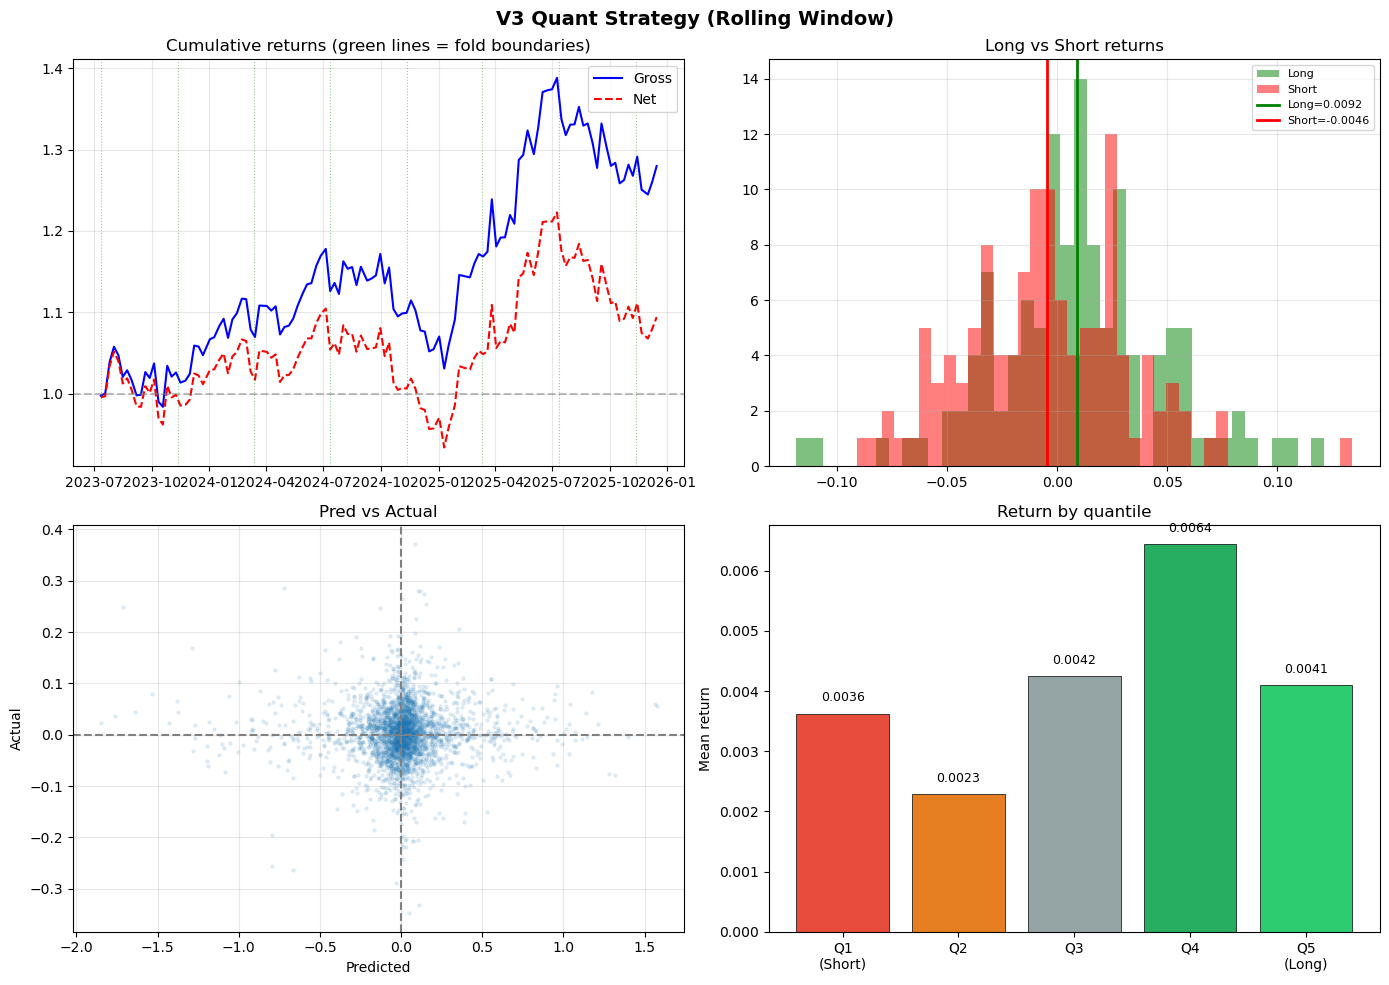

Mean IC: 0.0053 | IC Std: 0.1630 | IR: 0.0324 | IC>0: 53%
→ ❌ Near random


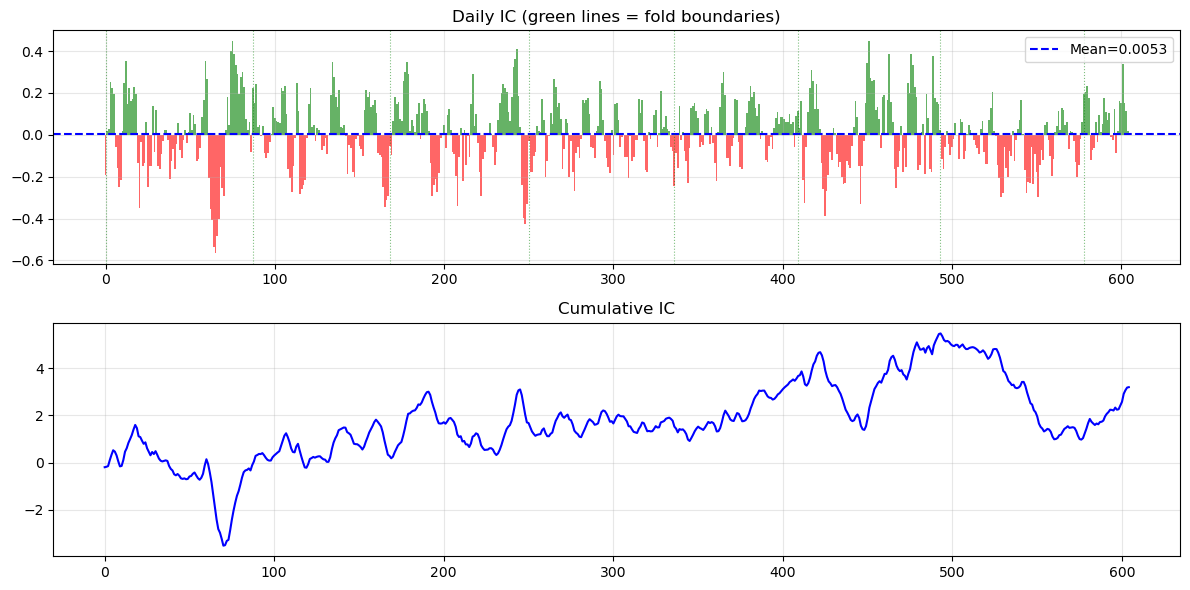

In [16]:
# =====================================================================
# Cell 9 替换：可视化（用 res_plot 代替 res_final）
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('V3 Quant Strategy (Rolling Window)', fontsize=14, fontweight='bold')

# 左上：累计收益 + fold 分割线
ax = axes[0, 0]
ax.plot(bt_final['date'], (1 + bt_final['gross_return']).cumprod(), 'b-', label='Gross', lw=1.5)
ax.plot(bt_final['date'], (1 + bt_final['net_return']).cumprod(), 'r--', label='Net', lw=1.5)
ax.axhline(y=1, color='gray', ls='--', alpha=0.5)
# 标注每个 fold 的分界线
for fm in fold_metrics:
    ax.axvline(x=fm['test_start'], color='green', ls=':', alpha=0.4, lw=0.8)
ax.legend()
ax.set_title('Cumulative returns (green lines = fold boundaries)')
ax.grid(True, alpha=0.3)

# 右上：Long vs Short 分布
ax = axes[0, 1]
ax.hist(bt_final['long_return'], bins=40, alpha=0.5, color='green', label='Long')
ax.hist(bt_final['short_return'], bins=40, alpha=0.5, color='red', label='Short')
ax.axvline(x=bt_final['long_return'].mean(), color='green', lw=2,
           label=f"Long={bt_final['long_return'].mean():.4f}")
ax.axvline(x=bt_final['short_return'].mean(), color='red', lw=2,
           label=f"Short={bt_final['short_return'].mean():.4f}")
ax.legend(fontsize=8)
ax.set_title('Long vs Short returns')
ax.grid(True, alpha=0.3)

# 左下：Pred vs Actual 散点图
ax = axes[1, 0]
s = res_plot.sample(min(3000, len(res_plot)))
ax.scatter(s['predicted'], s['actual'], alpha=0.1, s=5)
ax.axhline(y=0, color='gray', ls='--')
ax.axvline(x=0, color='gray', ls='--')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Pred vs Actual')
ax.grid(True, alpha=0.3)

# 右下：分位数收益
ax = axes[1, 1]
res_plot['q'] = pd.qcut(res_plot['predicted'], q=5,
                         labels=['Q1\n(Short)', 'Q2', 'Q3', 'Q4', 'Q5\n(Long)'])
qr = res_plot.groupby('q')['actual'].mean()
bars = ax.bar(qr.index, qr.values,
              color=['#e74c3c', '#e67e22', '#95a5a6', '#27ae60', '#2ecc71'],
              edgecolor='k', lw=0.5)
ax.axhline(y=0, color='k', ls='--', lw=0.5)
for b, v in zip(bars, qr.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.0002, f'{v:.4f}',
            ha='center', fontsize=9)
ax.set_title('Return by quantile')
ax.set_ylabel('Mean return')

plt.tight_layout()
plt.savefig('v3_rolling_results.png', dpi=150)
plt.show()


# =====================================================================
# Cell 10 替换：IC 分析（用 res_plot）
# =====================================================================

daily_ic = []
for dt, g in res_plot.groupby('date'):
    if len(g) < 5:
        continue
    ic, _ = stats.spearmanr(g['predicted'], g['actual'])
    if not np.isnan(ic):
        daily_ic.append({'date': dt, 'ic': ic})

idf = pd.DataFrame(daily_ic).sort_values('date')
mic, sic = idf['ic'].mean(), idf['ic'].std()
ir = mic / sic if sic > 0 else 0

print(f'Mean IC: {mic:.4f} | IC Std: {sic:.4f} | IR: {ir:.4f} | IC>0: {(idf["ic"] > 0).mean():.0%}')
if abs(mic) > 0.05:
    print('→ ✅ Good')
elif abs(mic) > 0.03:
    print('→ ⚠️ Weak')
else:
    print('→ ❌ Near random')

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

ax = axes[0]
ax.bar(range(len(idf)), idf['ic'],
       color=['g' if x > 0 else 'r' for x in idf['ic']], alpha=0.6, width=1)
ax.axhline(y=mic, color='blue', ls='--', label=f'Mean={mic:.4f}')
# fold 分界线
for fm in fold_metrics:
    idx_match = idf[idf['date'] >= fm['test_start']].index
    if len(idx_match) > 0:
        pos = list(idf.index).index(idx_match[0])
        ax.axvline(x=pos, color='green', ls=':', alpha=0.5, lw=0.8)
ax.legend()
ax.set_title('Daily IC (green lines = fold boundaries)')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(idf['ic'].cumsum().values, 'b-', lw=1.5)
ax.set_title('Cumulative IC')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. IC 分析

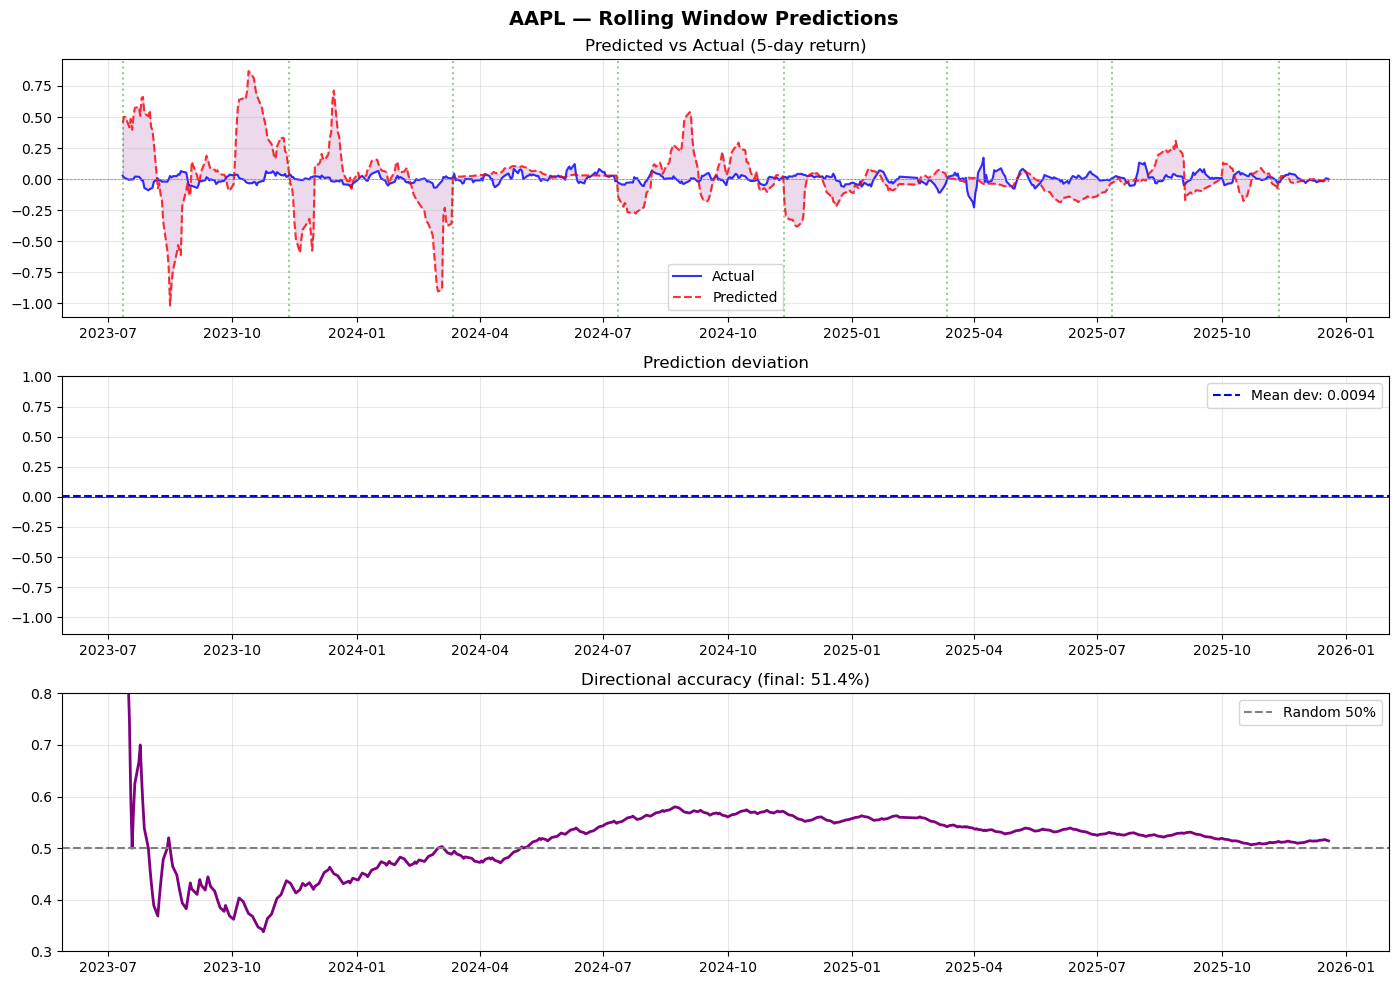


 AAPL Prediction Stats (Rolling Window)
  Samples:       605
  Date range:    2023-07-12 ~ 2025-12-19
  Mean dev:      0.0094
  Direction acc: 51.4%
  Correlation:   -0.0271


In [17]:
# ====================================================================
# Cell 10.5（新增）：单股预测（适配 rolling window）
# =====================================================================

def plot_stock_prediction_rolling(ticker, res_plot):
    """直接用 res_plot 中的预测结果，不再需要 model"""
    mask = res_plot[res_plot['ticker'] == ticker].copy()
    if len(mask) == 0:
        print(f"❌ {ticker} not in predictions")
        print(f"Available: {sorted(res_plot['ticker'].unique())}")
        return

    mask = mask.sort_values('date')
    dates = mask['date'].values
    actuals = mask['actual'].values
    preds = mask['predicted'].values

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'{ticker} — Rolling Window Predictions', fontsize=14, fontweight='bold')

    # 预测 vs 实际
    ax = axes[0]
    ax.plot(dates, actuals, 'b-', label='Actual', alpha=0.8, lw=1.5)
    ax.plot(dates, preds, 'r--', label='Predicted', alpha=0.8, lw=1.5)
    ax.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax.fill_between(dates, actuals, preds, alpha=0.15, color='purple')
    for fm in fold_metrics:
        ax.axvline(x=fm['test_start'], color='green', ls=':', alpha=0.4)
    ax.legend(fontsize=10)
    ax.set_title('Predicted vs Actual (5-day return)')
    ax.grid(True, alpha=0.3)

    # 偏差
    ax = axes[1]
    dev = preds - actuals
    colors = ['green' if d >= 0 else 'red' for d in dev]
    ax.bar(dates, dev, color=colors, alpha=0.6, width=2)
    ax.axhline(y=0, color='black', lw=0.5)
    ax.axhline(y=dev.mean(), color='blue', ls='--', label=f'Mean dev: {dev.mean():.4f}')
    ax.legend()
    ax.set_title('Prediction deviation')
    ax.grid(True, alpha=0.3)

    # 方向准确率
    ax = axes[2]
    correct = (np.sign(preds) == np.sign(actuals)).astype(int)
    cum_acc = pd.Series(correct).expanding().mean()
    ax.plot(dates, cum_acc, 'purple', lw=2)
    ax.axhline(y=0.5, color='gray', ls='--', label='Random 50%')
    ax.set_ylim(0.3, 0.8)
    ax.legend()
    ax.set_title(f'Directional accuracy (final: {correct.mean():.1%})')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{ticker}_rolling_pred.png', dpi=150, bbox_inches='tight')
    plt.show()

    corr = np.corrcoef(preds, actuals)[0, 1]
    print(f"\n{'='*40}")
    print(f" {ticker} Prediction Stats (Rolling Window)")
    print(f"{'='*40}")
    print(f"  Samples:       {len(mask)}")
    print(f"  Date range:    {pd.Timestamp(dates[0]).strftime('%Y-%m-%d')} ~ {pd.Timestamp(dates[-1]).strftime('%Y-%m-%d')}")
    print(f"  Mean dev:      {dev.mean():.4f}")
    print(f"  Direction acc: {correct.mean():.1%}")
    print(f"  Correlation:   {corr:.4f}")

plot_stock_prediction_rolling('AAPL', res_plot)

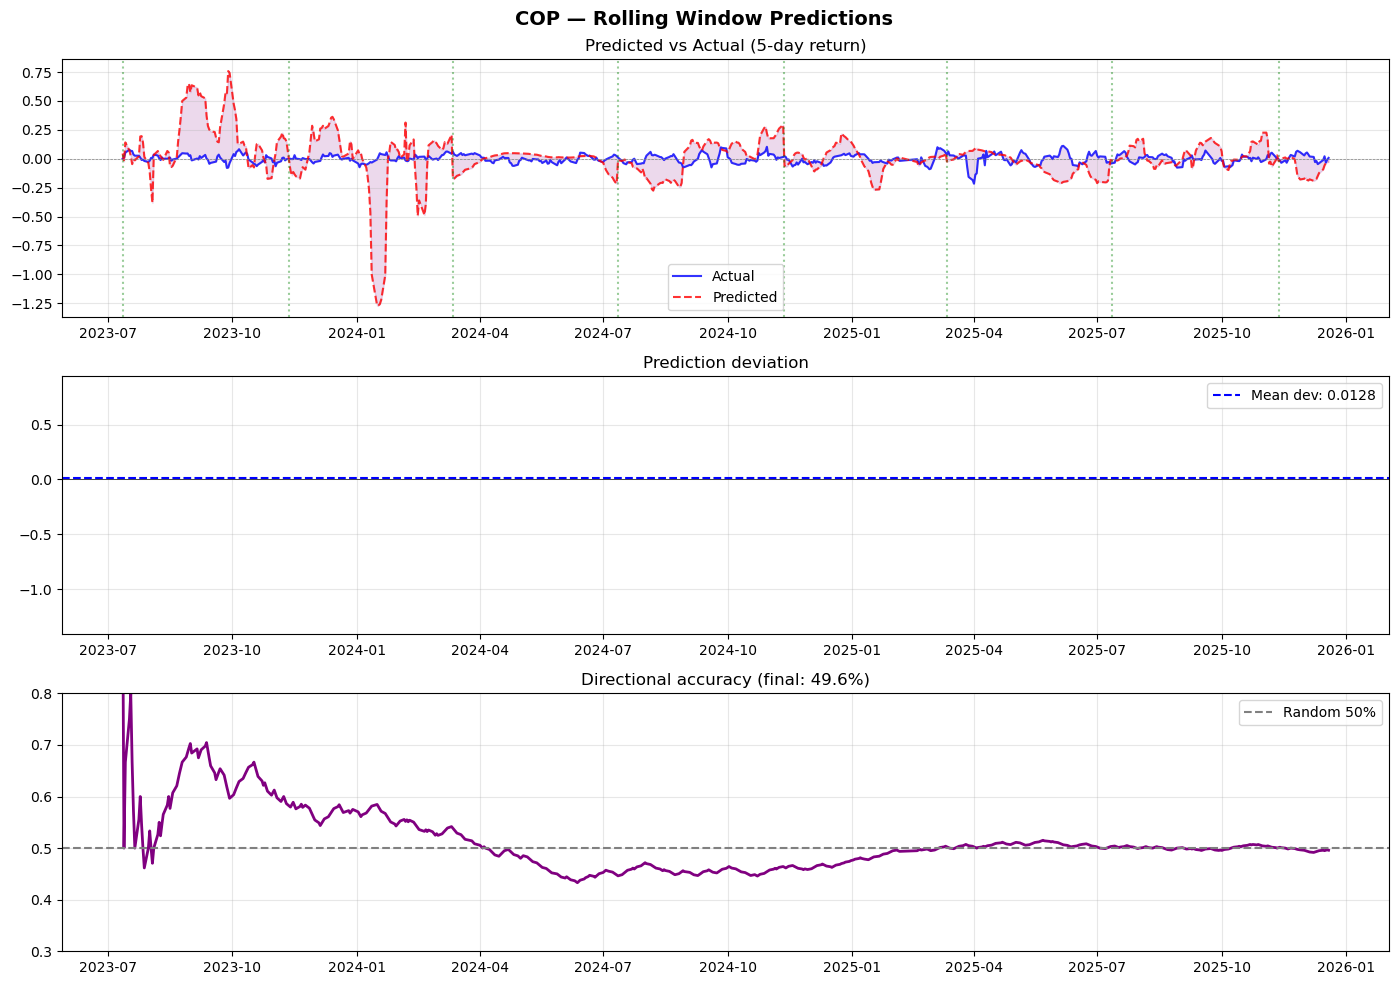


 COP Prediction Stats (Rolling Window)
  Samples:       605
  Date range:    2023-07-12 ~ 2025-12-19
  Mean dev:      0.0128
  Direction acc: 49.6%
  Correlation:   -0.0376


In [18]:
plot_stock_prediction_rolling('COP', res_plot)

## 11. 可调参数

| 参数 | 位置 | 当前值 | 试试 |
|------|------|--------|------|
| `d_model` | Cell 4 | 192 | 128 / 256 |
| `num_layers` | Cell 4 | 4 | 2 / 6 |
| `nhead` | Cell 4 | 6 | 3 / 8 |
| `dropout` | Cell 4 | 0.15 | 0.1 / 0.25 |
| `rank/mse/ic weight` | Cell 5 | 0.5/0.2/0.3 | 0.7/0.1/0.2 |
| `NUM_EPOCHS` | Cell 6 | 80 | 60 / 120 |
| `T_max` | Cell 6 | 40 | 30 / 50 |
| `lr` | Cell 6 | 3e-4 | 1e-4 / 5e-4 |
| `TOP_N` | Cell 7 | 3 | 2 / 5 |
| `REBAL_FREQ` | Cell 7 | 5 | 3 / 10 |
| `train_ratio` | Cell 3 | 0.70 | 0.75 / 0.80 |